In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
sb.set() # set the default Seaborn style for graphics

In [2]:
df = pd.read_csv("Students Social Media Addiction.csv")

In [3]:
df["Relationship_Status"] = df["Relationship_Status"].astype("category")

In [4]:
df["Relationship_Status"] = df["Relationship_Status"].cat.remove_categories("Complicated")

In [5]:
df = df.dropna(subset=['Relationship_Status'])

In [6]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [7]:
Relationship = ['In Relationship', 'Single']	#0 = in relationship, 1 = single

In [8]:
enc = OrdinalEncoder(categories = [Relationship])

In [9]:
df['Relationship_Status'] = enc.fit_transform(df[['Relationship_Status']])

In [10]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,0.0,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,1.0,0,3
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,1.0,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,0.0,2,7
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,1.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,0.0,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,1.0,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,0.0,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,1.0,2,4


<Axes: xlabel='Relationship_Status', ylabel='count'>

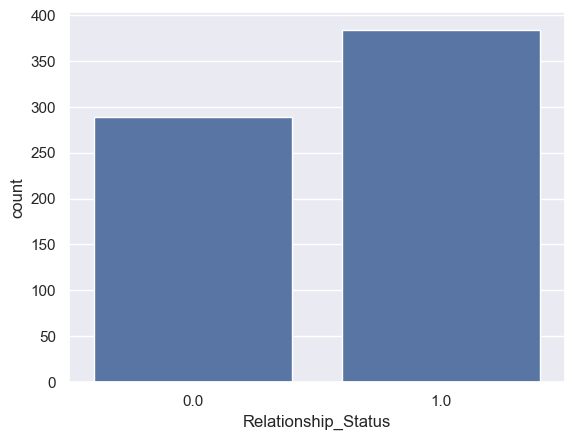

In [12]:
sb.countplot(x="Relationship_Status", data = df)

In [13]:
# Extract Response and Predictors
predictors = ["Mental_Health_Score", "Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours","Addicted_Score"]
predictors2 = ["Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours"]
predictors3 = ["Mental_Health_Score", "Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours", "Age"]

y = pd.DataFrame(df["Relationship_Status"])
X = pd.DataFrame(df[predictors])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state = 11)

In [15]:
X_train.shape

(471, 4)

In [16]:
X_test.shape

(202, 4)

In [17]:
model = LogisticRegression()

In [18]:
model.fit(X_train, y_train)

C:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [19]:
y_pred = model.predict(X_test)

model.score(X_text, y_test)

In [20]:
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [21]:
model.score(X_test, y_test)
model.score(X_train, y_train)

0.583864118895966

In [22]:
print(confusion_matrix(y_test, y_test_pred))

[[ 10  85]
 [  5 102]]


<Axes: >

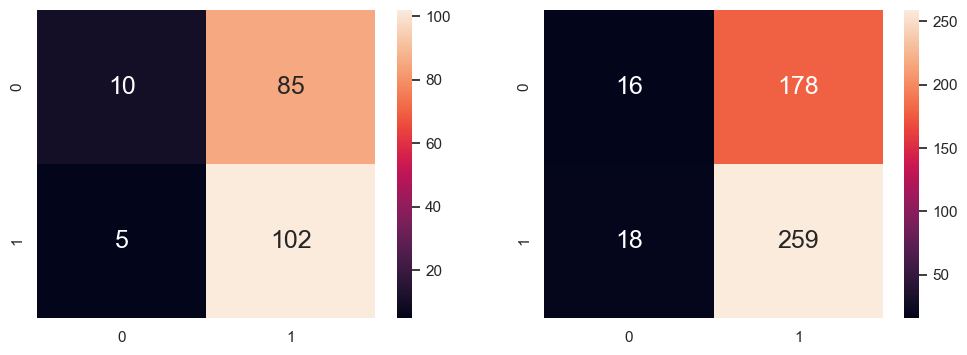

In [23]:
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_test, y_test_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

In [24]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.67      0.11      0.18        95
         1.0       0.55      0.95      0.69       107

    accuracy                           0.55       202
   macro avg       0.61      0.53      0.44       202
weighted avg       0.60      0.55      0.45       202



In [25]:
#Problem Statement: Can we predict if a person is single or in a relationship if we use 
#"Mental_Health_Score", "Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours" as their predictors

#Since we used logistic regression, we have to use classification report instead of R^2 and Mean Squared error
#due to the categorical prediction
#In the classification report, it shows how strong the model predicts between 1(single), 0(In Relationship)
#So from the report we can infer that the model is more biased in predicting single than In relationship. 
#As we can see the recall is described as how correctly the model has predicted the 2 categories where 94% of single
#were predicted correct with the "Mental_Health_Score", "Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours". 
#While those in relationship, the "Mental_Health_Score", "Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours" 
#Could only be predicted correct 11% of the time. This can be affected by outside factors where relationship 
#situations matters. For example, some relationshops are more low maintenenace which could be more sleep and 
#less usage of internet, while the other way also.
#While singles, they may have outside factors but their prediciton is relatively accurate.
#Hence, This model can be used to estimate single people patterns in terms of social media addiction better
#while relationship is a bit mroe difficult due to their outside factors.

In [26]:
X = pd.DataFrame(df[predictors2])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state = 11)

In [28]:
model.fit(X_train, y_train)

C:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [29]:
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [30]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.62      0.05      0.10        95
         1.0       0.54      0.97      0.69       107

    accuracy                           0.54       202
   macro avg       0.58      0.51      0.39       202
weighted avg       0.58      0.54      0.41       202



<Axes: >

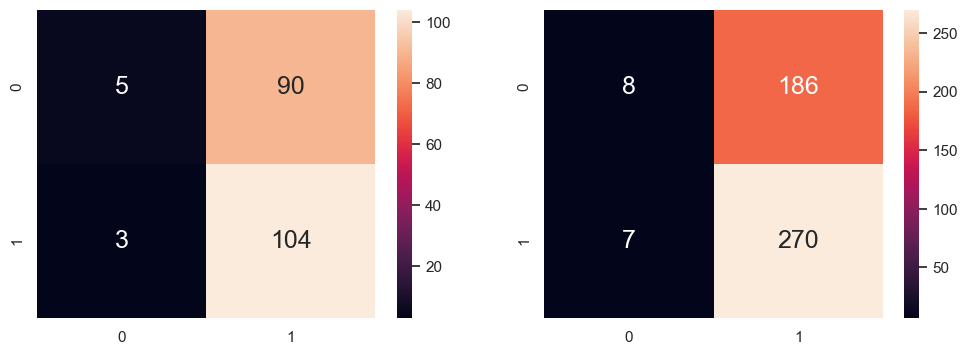

In [31]:
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_test, y_test_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

C:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

         0.0       0.62      0.05      0.10        95
         1.0       0.54      0.97      0.69       107

    accuracy                           0.54       202
   macro avg       0.58      0.51      0.39       202
weighted avg       0.58      0.54      0.41       202



<Axes: >

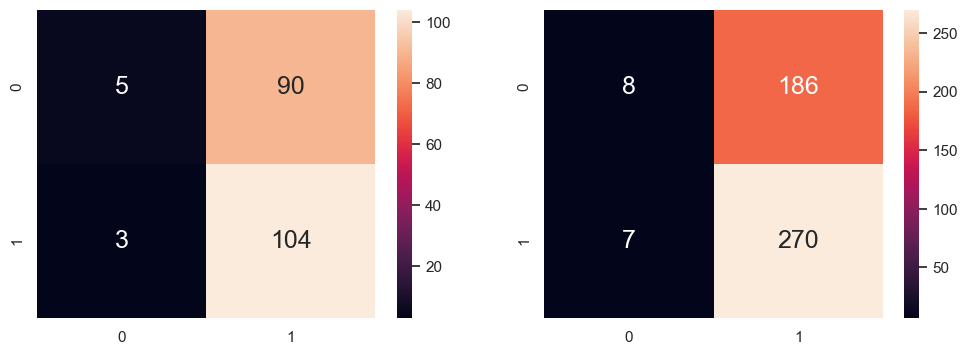

In [32]:
X = pd.DataFrame(df[predictors3])

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state = 11)

model.fit(X_train, y_train)

y_test_pred3 = model.predict(X_test)
y_train_pred3 = model.predict(X_train)

print(classification_report(y_test, y_test_pred))

f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_test, y_test_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

C:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95        90
         1.0       0.00      0.00      0.00         7

    accuracy                           0.91        97
   macro avg       0.46      0.49      0.48        97
weighted avg       0.86      0.91      0.88        97



<Axes: >

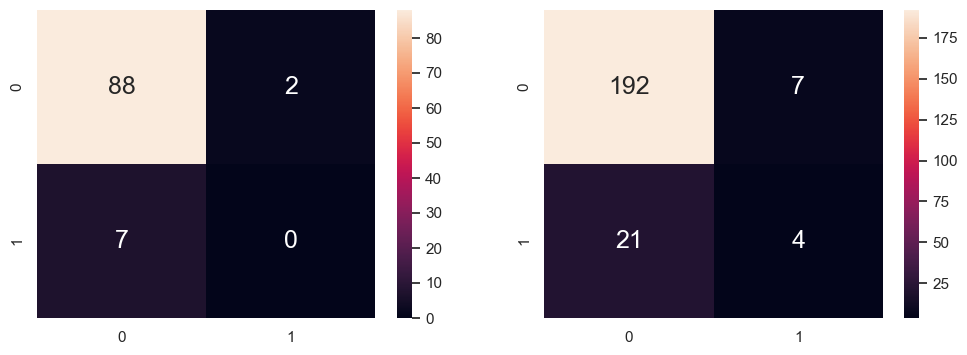

In [37]:
y = pd.DataFrame(df2["Relationship_Status"])
X = pd.DataFrame(df2[predictors])

X = pd.DataFrame(df2[predictors3])

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state = 11)

model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

print(classification_report(y_test, y_test_pred))

f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_test, y_test_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])